# **Step : 1 Install Libraries**

In [ ]:
pip install numpy pandas matplotlib seaborn torch torchvision scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 95.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
# General utilities
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
from PIL import Image

# Machine learning utilities
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# PyTorch libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

In [ ]:
# prompt: Mount the Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Define dataset paths
base_directory = "/content/drive/MyDrive/M.Tech Projects/Brain Tumor Detection from MRI Images Using Deep Learning/Dataset/Brain Tumor MRI Dataset"
train_dir = os.path.join(base_directory, "Training")
test_dir = os.path.join(base_directory, "Testing")

# Label mapping for tumor classes
label_map = {
    "notumor": 0,
    "glioma": 1,
    "meningioma": 2,
    "pituitary": 3
}

# Check available categories in training data
categories = os.listdir(train_dir)
print("Tumor Categories:", categories)

# Set device for training (GPU if available)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Function to create a dataset DataFrame
def create_dataset(path, sample_fraction=0.3):
    dataset_list = []
    for category in categories:
        category_path = os.path.join(path, category)
        for file_name in os.listdir(category_path):
            file_path = os.path.join(category_path, file_name)
            # Ensure we only add image files
            if os.path.isfile(file_path) and file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                dataset_list.append([file_path, category])

    df = pd.DataFrame(dataset_list, columns=["file_path", "label"])

    # Reduce dataset size
    df = df.sample(frac=sample_fraction, random_state=42).reset_index(drop=True)

    return df

# Create reduced datasets
train_df = create_dataset(train_dir)
test_df = create_dataset(test_dir)

# Convert labels to numerical format
train_df["label"] = train_df["label"].map(label_map)
test_df["label"] = test_df["label"].map(label_map)

# Split test set further into validation and final test set
test_df_split, val_df_split = train_test_split(test_df, test_size=0.5, random_state=42)
test_df_split = test_df_split.reset_index(drop=True)
val_df_split = val_df_split.reset_index(drop=True)

# Print reduced dataset sizes
print(f"Reduced Training Set: {len(train_df)} images")
print(f"Reduced Validation Set: {len(val_df_split)} images")
print(f"Reduced Test Set: {len(test_df_split)} images")

Tumor Categories: ['notumor', 'meningioma', 'pituitary', 'glioma']
Using device: cuda
Reduced Training Set: 1714 images
Reduced Validation Set: 197 images
Reduced Test Set: 196 images


# **Step 4: Exploring and Visualizing the Reduced Dataset**

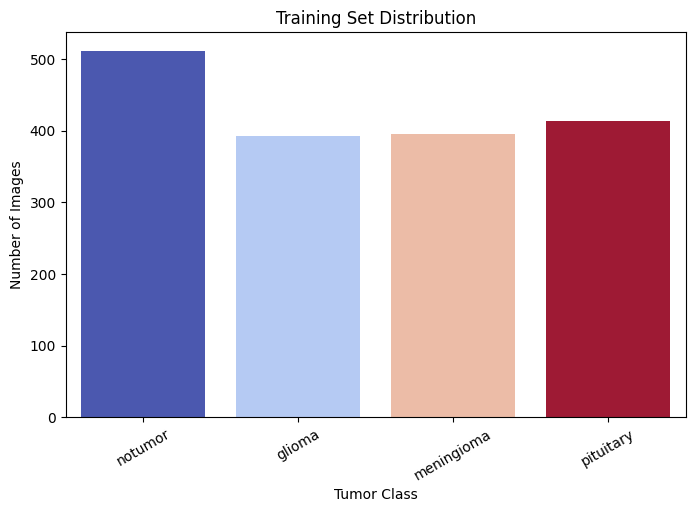

In [ ]:
def plot_class_distribution(dataset_type, dataframe):
    """
    This function plots the distribution of tumor types in the reduced dataset.
    """
    counts = dataframe["label"].value_counts()

    plt.figure(figsize=(8, 5))
    sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="coolwarm", legend=False)
    plt.xlabel("Tumor Class")
    plt.ylabel("Number of Images")
    plt.title(f"{dataset_type.capitalize()} Set Distribution")
    plt.xticks(ticks=range(4), labels=label_map.keys(), rotation=30)
    plt.show()

# Plot distribution for Training and Validation sets
plot_class_distribution("Training", train_df)

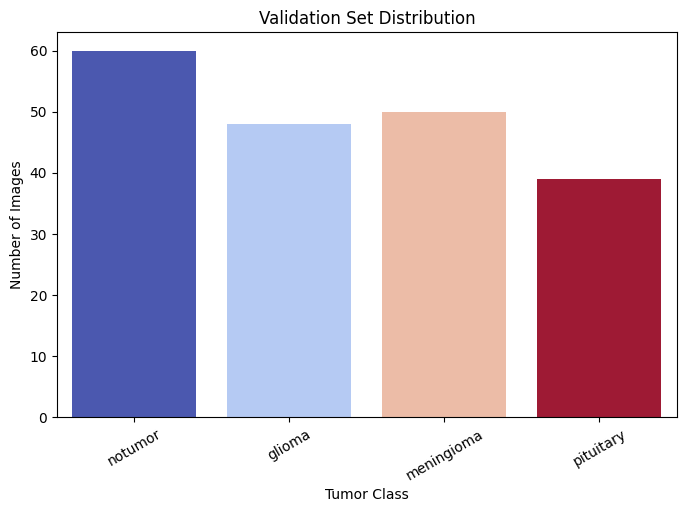

In [ ]:
plot_class_distribution("Validation", val_df_split)

# **Step 5: Displaying Sample MRI Images**

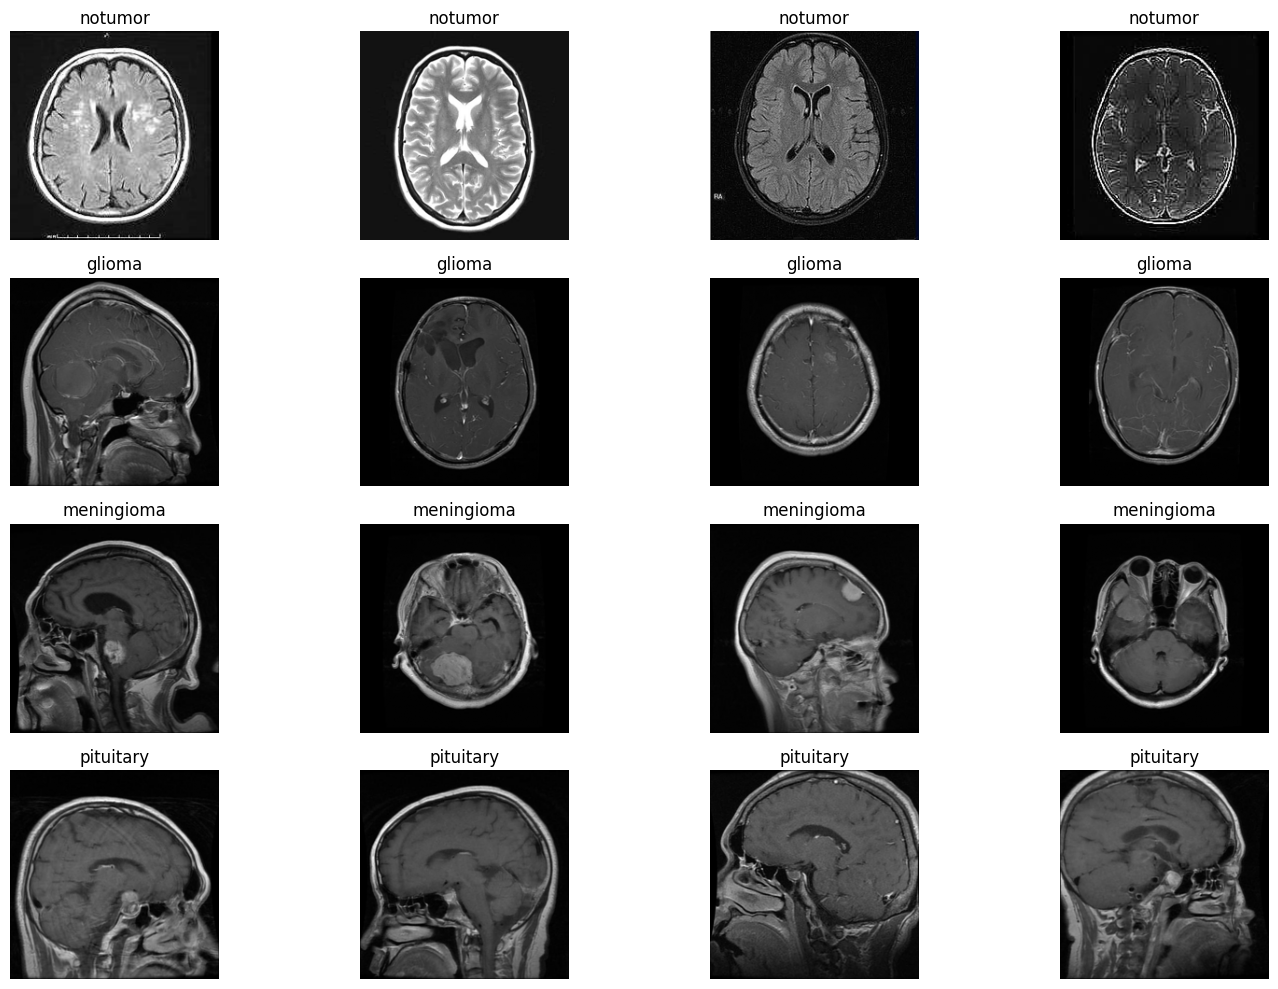

In [ ]:
def display_images(dataset_type, dataframe, num_images=4, image_size=(224, 224)):
    """
    Displays sample MRI images from each tumor category.
    """
    fig, axes = plt.subplots(len(label_map), num_images, figsize=(15, 10))

    for row, (label_name, label_id) in enumerate(label_map.items()):
        sample_images = dataframe[dataframe["label"] == label_id].sample(num_images)["file_path"].tolist()

        for col, img_path in enumerate(sample_images):
            img = Image.open(img_path).resize(image_size)
            axes[row, col].imshow(img, cmap='gray')
            axes[row, col].axis('off')
            axes[row, col].set_title(label_name)

    plt.tight_layout()
    plt.show()

# Show images from the reduced training dataset
display_images("Training", train_df)

# **Step 6: Preprocessing the Images**

In [ ]:
# Define preprocessing transformations for training images
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Standard resizing
    transforms.RandomHorizontalFlip(),  # Apply random horizontal flip
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Introduce slight positional shifts
    transforms.ColorJitter(brightness=(0.8, 1.2)),  # Adjust brightness slightly
    transforms.RandomRotation(10),  # Rotate image randomly
    transforms.ToTensor(),  # Convert image to tensor format
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Apply normalization
])

# Define preprocessing transformations for test/validation images
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Standard resizing
    transforms.ToTensor(),  # Convert image to tensor format
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Apply normalization
])

# **Step 7: Structuring the Dataset for PyTorch**

In [ ]:
class ImageDataset(Dataset):
    """
    Custom PyTorch Dataset class to load MRI images and apply transformations.
    """
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.dataframe.iloc[idx, 1]
        img = Image.open(img_path).convert('RGB')  # Ensure image is in RGB format

        if self.transform:
            img = self.transform(img)

        return img, label

# **Step 8: Splitting the Dataset and Creating DataLoaders**

In [ ]:
# Define batch size
batch_size = 16  # Reduced batch size for faster training

# Create dataset objects
train_dataset = ImageDataset(train_df, transform=train_transform)
val_dataset = ImageDataset(val_df_split, transform=test_transform)
test_dataset = ImageDataset(test_df_split, transform=test_transform)

# Create DataLoaders for batch processing
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Print dataset sizes
print(f"Reduced Training Set: {len(train_dataset)} images")
print(f"Reduced Validation Set: {len(val_dataset)} images")
print(f"Reduced Test Set: {len(test_dataset)} images")

Reduced Training Set: 1714 images
Reduced Validation Set: 197 images
Reduced Test Set: 196 images


# **Step 9: Building the CNN Model for Classification**

In [ ]:
class BrainTumorCNN(nn.Module):
    """
    Custom Convolutional Neural Network (CNN) for brain tumor classification.
    """
    def __init__(self, num_classes=4):
        super(BrainTumorCNN, self).__init__()

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.5)

        # Convolutional Layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)   # (B, 32, 224, 224)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # (B, 64, 112, 112)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # (B, 128, 56, 56)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1) # (B, 256, 28, 28)
        self.conv5 = nn.Conv2d(256, 256, kernel_size=3, padding=1) # (B, 256, 14, 14)

        # Fully Connected Layers
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(256 * 7 * 7, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = self.pool(self.relu(self.conv4(x)))
        x = self.pool(self.relu(self.conv5(x)))

        x = self.flatten(x)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

# Instantiate the model
model = BrainTumorCNN(num_classes=4).to(device)

# **Step 10: Setting Up the Training Process**

In [ ]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0007)

# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=15):
    """
    Function to train the CNN model with validation tracking.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct_val / total_val

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.2f}%")
        print("#" * 80)

    return history

# **Step 11: Training the Model**

In [ ]:
# Start training
print("Starting model training...")
history = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=15)

Starting model training...
Epoch [1/15]
Train Loss: 1.1939, Train Accuracy: 44.05%
Val Loss: 1.0644, Val Accuracy: 53.30%
################################################################################
Epoch [2/15]
Train Loss: 0.9310, Train Accuracy: 61.55%
Val Loss: 0.8400, Val Accuracy: 63.96%
################################################################################
Epoch [3/15]
Train Loss: 0.7528, Train Accuracy: 69.95%
Val Loss: 0.6824, Val Accuracy: 72.59%
################################################################################
Epoch [4/15]
Train Loss: 0.7005, Train Accuracy: 73.34%
Val Loss: 0.6375, Val Accuracy: 73.10%
################################################################################
Epoch [5/15]
Train Loss: 0.6200, Train Accuracy: 74.68%
Val Loss: 0.6047, Val Accuracy: 74.11%
################################################################################
Epoch [6/15]
Train Loss: 0.5714, Train Accuracy: 77.77%
Val Loss: 0.6514, Val Accuracy: 74.11

In [ ]:
# prompt: Save the model

# Save the trained model state dictionary
torch.save(model.state_dict(), "/content/drive/MyDrive/M.Tech Projects/Brain Tumor Detection from MRI Images Using Deep Learning/Models/brain_tumor_cnn.pth")
print("Model saved successfully.")

Model saved successfully.


# **Evaluating Model Performance**

In [ ]:
# Evaluate model on test set
def evaluate_model(model, test_loader):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    correct = 0
    total = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")

    return all_labels, all_preds

# Run model evaluation
true_labels, predicted_labels = evaluate_model(model, test_loader)

Test Accuracy: 85.20%


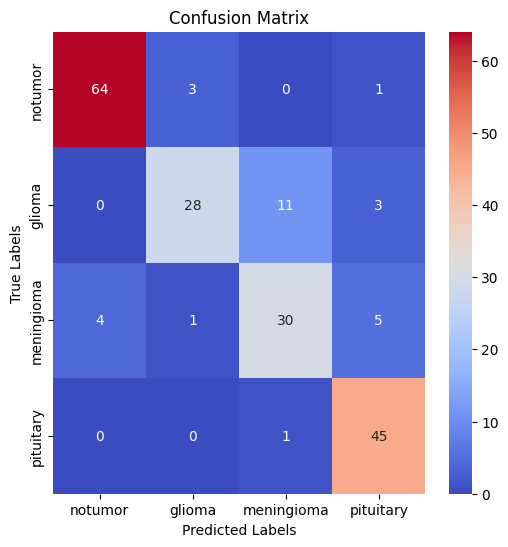

In [ ]:
# Plot confusion matrix
def plot_confusion_matrix(true_labels, predicted_labels):
    cm = confusion_matrix(true_labels, predicted_labels)
    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", xticklabels=label_map.keys(), yticklabels=label_map.keys())
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix")
    plt.show()

# Generate confusion matrix
plot_confusion_matrix(true_labels, predicted_labels)

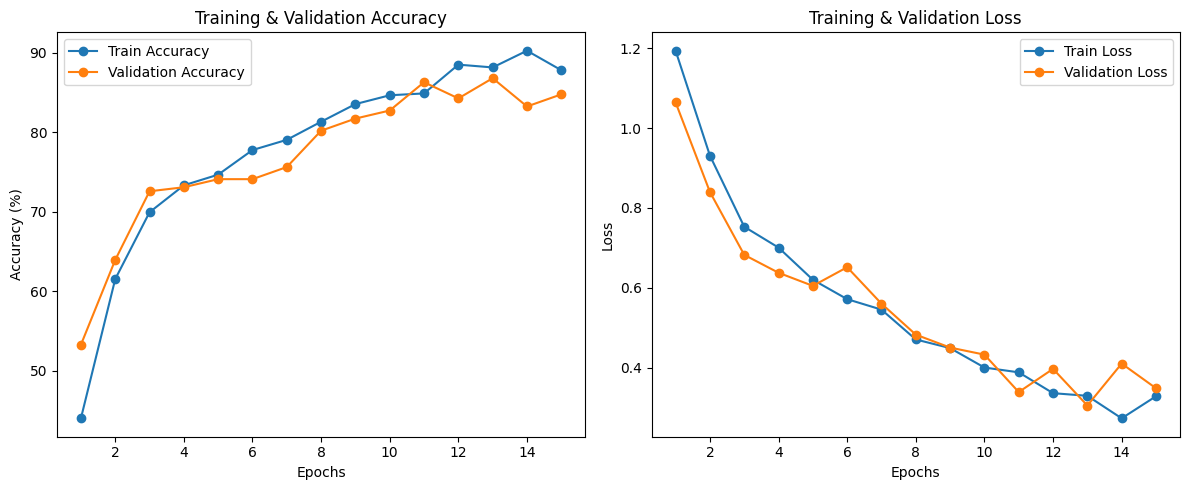

In [ ]:
# Plot training accuracy and loss trends
def plot_training_curves(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12,5))

    # Accuracy Plot
    plt.subplot(1,2,1)
    plt.plot(epochs, history["train_acc"], label="Train Accuracy", marker="o")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy", marker="o")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title("Training & Validation Accuracy")
    plt.legend()

    # Loss Plot
    plt.subplot(1,2,2)
    plt.plot(epochs, history["train_loss"], label="Train Loss", marker="o")
    plt.plot(epochs, history["val_loss"], label="Validation Loss", marker="o")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Generate training curves
plot_training_curves(history)

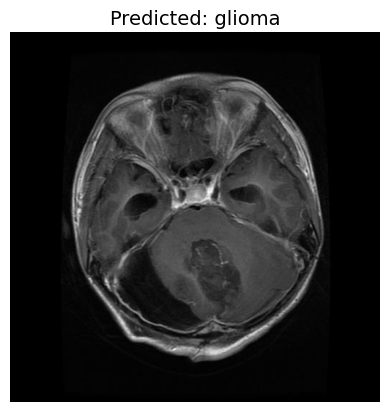

In [ ]:
def predict_image(image_path, model, transform):
    """
    Loads an MRI image, preprocesses it, and runs inference using the trained model.
    """
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)  # Apply transforms and add batch dimension

    with torch.no_grad():
        output = model(image)
        _, predicted_class = torch.max(output, 1)

    class_names = list(label_map.keys())
    predicted_label = class_names[predicted_class.item()]

    plt.imshow(Image.open(image_path), cmap='gray')
    plt.title(f"Predicted: {predicted_label}", fontsize=14)
    plt.axis('off')
    plt.show()

# Example usage (Replace with actual MRI image path)
test_image_path = "/content/drive/MyDrive/M.Tech Projects/Brain Tumor Detection from MRI Images Using Deep Learning/Dataset/Brain Tumor MRI Dataset/Testing/glioma/Te-glTr_0000.jpg"
predict_image(test_image_path, model, test_transform)

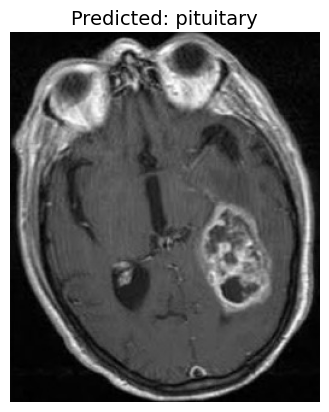

In [ ]:
def predict_image(image_path, model, transform):
    """
    Loads an MRI image, preprocesses it, and runs inference using the trained model.
    """
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)  # Apply transforms and add batch dimension

    with torch.no_grad():
        output = model(image)
        _, predicted_class = torch.max(output, 1)

    class_names = list(label_map.keys())
    predicted_label = class_names[predicted_class.item()]

    plt.imshow(Image.open(image_path), cmap='gray')
    plt.title(f"Predicted: {predicted_label}", fontsize=14)
    plt.axis('off')
    plt.show()

# Example usage (Replace with actual MRI image path)
test_image_path = "/content/drive/MyDrive/M.Tech Projects/Brain Tumor Detection from MRI Images Using Deep Learning/Dataset/Brain Tumor MRI Dataset/Testing/meningioma/Te-meTr_0001.jpg"
predict_image(test_image_path, model, test_transform)

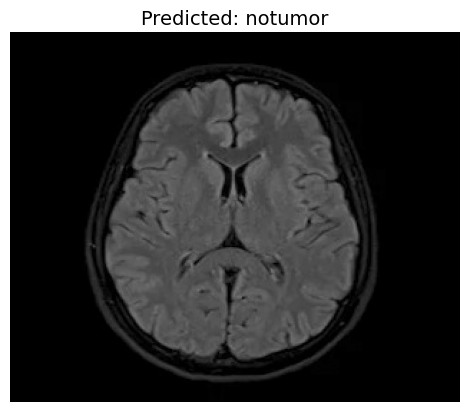

In [ ]:
def predict_image(image_path, model, transform):
    """
    Loads an MRI image, preprocesses it, and runs inference using the trained model.
    """
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)  # Apply transforms and add batch dimension

    with torch.no_grad():
        output = model(image)
        _, predicted_class = torch.max(output, 1)

    class_names = list(label_map.keys())
    predicted_label = class_names[predicted_class.item()]

    plt.imshow(Image.open(image_path), cmap='gray')
    plt.title(f"Predicted: {predicted_label}", fontsize=14)
    plt.axis('off')
    plt.show()

# Example usage (Replace with actual MRI image path)
test_image_path = "/content/drive/MyDrive/M.Tech Projects/Brain Tumor Detection from MRI Images Using Deep Learning/Dataset/Brain Tumor MRI Dataset/Testing/notumor/Te-noTr_0002.jpg"
predict_image(test_image_path, model, test_transform)

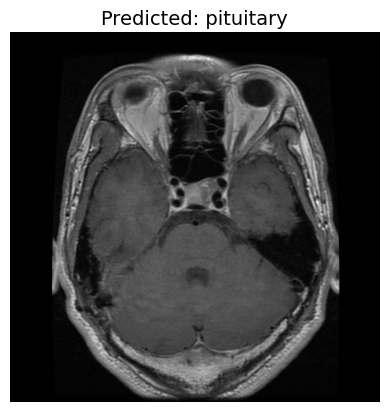

In [ ]:
def predict_image(image_path, model, transform):
    """
    Loads an MRI image, preprocesses it, and runs inference using the trained model.
    """
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)  # Apply transforms and add batch dimension

    with torch.no_grad():
        output = model(image)
        _, predicted_class = torch.max(output, 1)

    class_names = list(label_map.keys())
    predicted_label = class_names[predicted_class.item()]

    plt.imshow(Image.open(image_path), cmap='gray')
    plt.title(f"Predicted: {predicted_label}", fontsize=14)
    plt.axis('off')
    plt.show()

# Example usage (Replace with actual MRI image path)
test_image_path = "/content/drive/MyDrive/M.Tech Projects/Brain Tumor Detection from MRI Images Using Deep Learning/Dataset/Brain Tumor MRI Dataset/Testing/pituitary/Te-piTr_0000.jpg"
predict_image(test_image_path, model, test_transform)

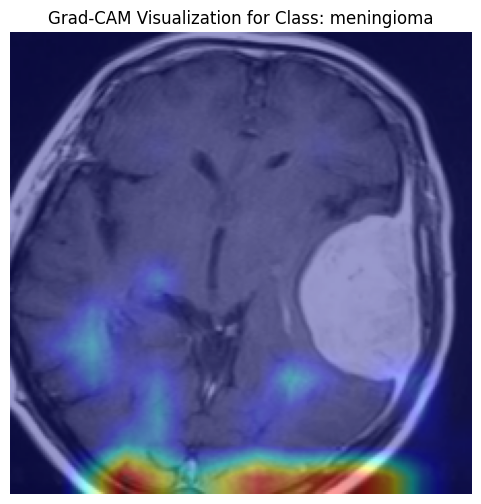

In [ ]:
import cv2
import torch.nn.functional as F
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt # Ensure matplotlib is imported here as well

def compute_gradcam(model, image_tensor, target_class):
    """
    Computes Grad-CAM heatmap to visualize feature importance.
    """
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Ensure image_tensor has a batch dimension
    image_tensor = image_tensor.unsqueeze(0).to(device)

    # We need to access the intermediate output of conv5
    # We can do this by registering a hook on the conv5 layer
    activations = None
    gradients = None

    def activations_hook(module, input, output):
        nonlocal activations
        activations = output

    def gradients_hook(module, grad_input, grad_output):
        nonlocal gradients
        gradients = grad_output[0]

    # Register hooks on the last convolutional layer (conv5)
    hook_a = model.conv5.register_forward_hook(activations_hook)
    hook_g = model.conv5.register_full_backward_hook(gradients_hook) # Use full_backward_hook

    # Forward pass to get the activations and the output
    output = model(image_tensor)

    # Zero gradients before backward pass
    model.zero_grad()

    # Get predicted class activation
    # If target_class is None, use the model's predicted class
    if target_class is None:
        _, target_class = torch.max(output, 1)
        target_class = target_class.item()

    # Ensure target_class is a scalar integer
    if isinstance(target_class, torch.Tensor):
        target_class = target_class.item()

    # Compute the gradient of the target class score with respect to the output
    # of the last convolutional layer
    one_hot_output = torch.zeros(output.size()).to(device)
    one_hot_output[0][target_class] = 1
    output.backward(gradient=one_hot_output, retain_graph=True) # Use retain_graph=True if you plan more backward passes later

    # Remove the hooks
    hook_a.remove()
    hook_g.remove()

    # Get the feature map activations and the gradients
    # Shape of activations should be (1, num_filters, H, W) -> squeeze to (num_filters, H, W)
    # Shape of gradients should be (1, num_filters, H, W) -> squeeze to (num_filters, H, W)
    activations = activations.squeeze(0).cpu().data.numpy()
    gradients = gradients.squeeze(0).cpu().data.numpy()

    # Compute the weights (alpha_k) using Global Average Pooling of gradients
    # Weights shape: (num_filters,)
    weights = np.mean(gradients, axis=(1, 2)) # Mean over H and W dimensions

    # Compute weighted heatmap
    # Multiply weights (num_filters,) with activations (num_filters, H, W)
    # Add a new dimension to weights for broadcasting: (num_filters, 1, 1)
    heatmap = np.sum(weights[:, None, None] * activations, axis=0) # Sum across filters

    # Apply ReLU to the heatmap (only positive contributions)
    heatmap = np.maximum(heatmap, 0)

    # Normalize the heatmap to [0, 1]
    max_val = np.max(heatmap)
    if max_val == 0: # Handle case where all values are zero
        heatmap = np.zeros_like(heatmap)
    else:
        heatmap = heatmap / max_val

    # Scale to 0-255 and convert to uint8
    # Resize the heatmap to the original image size
    heatmap = cv2.resize(heatmap, (224, 224)) # Assuming original image size was 224x224
    heatmap = np.uint8(255 * heatmap)

    # Overlay heatmap onto original MRI image
    # Denormalize the image for display if it was normalized
    # (Assuming mean and std used in test_transform)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    # Reverse the normalization and permute dimensions for display
    img = image_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    img = std * img + mean # Denormalize
    img = np.clip(img, 0, 1) * 255 # Scale to 0-255
    img = img.astype(np.uint8)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    # Need to convert RGB to BGR for cv2 operations
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    overlay = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    plt.figure(figsize=(6,6))
    # Convert back to RGB for matplotlib display
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    # Map target_class back to its label name for the title
    label_names = list(label_map.keys())
    predicted_label_name = label_names[target_class]
    plt.title(f"Grad-CAM Visualization for Class: {predicted_label_name}")
    plt.show()

# Example usage (you can keep the same example usage)
sample_image_path = "/content/drive/MyDrive/M.Tech Projects/Brain Tumor Detection from MRI Images Using Deep Learning/Dataset/Brain Tumor MRI Dataset/Testing/meningioma/Te-me_0012.jpg"
sample_image = test_transform(Image.open(sample_image_path).convert("RGB"))
# You can set target_class to None to use the model's predicted class
compute_gradcam(model, sample_image, target_class=2)

# **Step 16: Fine-Tuning Transfer Learning Models**

In [ ]:
# Load ResNet18 model
resnet18 = models.resnet18(pretrained=True)

# Modify the final classification layer
num_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_features, 4)  # Adjust for 4 classes

# Send model to GPU
resnet18 = resnet18.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet18.parameters(), lr=0.0003)

# Function to fine-tune ResNet18
def fine_tune_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=15):
    model.train()
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(num_epochs):
        running_loss, correct_train, total_train = 0.0, 0, 0

        # Training loop
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train

        # Validation loop
        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct_val / total_val

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] → Train Accuracy: {train_acc:.2f}% | Val Accuracy: {val_acc:.2f}%")

    return history

# Fine-tune ResNet18
print("Fine-tuning ResNet18...")
resnet_history = fine_tune_model(resnet18, train_loader, val_loader, criterion, optimizer, num_epochs=15)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 160MB/s]


Fine-tuning ResNet18...
Epoch [1/15] → Train Accuracy: 82.79% | Val Accuracy: 84.26%
Epoch [2/15] → Train Accuracy: 67.50% | Val Accuracy: 84.77%
Epoch [3/15] → Train Accuracy: 83.49% | Val Accuracy: 91.37%
Epoch [4/15] → Train Accuracy: 90.72% | Val Accuracy: 93.91%
Epoch [5/15] → Train Accuracy: 92.65% | Val Accuracy: 94.42%
Epoch [6/15] → Train Accuracy: 94.34% | Val Accuracy: 85.79%
Epoch [7/15] → Train Accuracy: 93.23% | Val Accuracy: 94.42%
Epoch [8/15] → Train Accuracy: 94.57% | Val Accuracy: 92.89%
Epoch [9/15] → Train Accuracy: 95.33% | Val Accuracy: 91.37%
Epoch [10/15] → Train Accuracy: 94.63% | Val Accuracy: 96.45%
Epoch [11/15] → Train Accuracy: 96.44% | Val Accuracy: 93.91%
Epoch [12/15] → Train Accuracy: 95.74% | Val Accuracy: 90.86%
Epoch [13/15] → Train Accuracy: 96.27% | Val Accuracy: 91.88%
Epoch [14/15] → Train Accuracy: 96.38% | Val Accuracy: 94.92%
Epoch [15/15] → Train Accuracy: 96.44% | Val Accuracy: 93.91%


In [ ]:
# prompt: Fine-Tuning Transfer Learning Models save the model

# Save the fine-tuned ResNet18 model
model_save_path = '/content/drive/MyDrive/M.Tech Projects/Brain Tumor Detection from MRI Images Using Deep Learning/Models/resnet18_finetuned_model.pth'
torch.save(resnet18.state_dict(), model_save_path)
print(f"Fine-tuned ResNet18 model saved to {model_save_path}")

Fine-tuned ResNet18 model saved to /content/drive/MyDrive/M.Tech Projects/Brain Tumor Detection from MRI Images Using Deep Learning/Models/resnet18_finetuned_model.pth


In [ ]:
# Load pretrained VGG16 model
vgg16 = models.vgg16(pretrained=True)

# Modify the classifier
vgg16.classifier[-1] = nn.Linear(4096, 4)  # Adjust for 4 tumor classes

# Send model to GPU
vgg16 = vgg16.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(vgg16.parameters(), lr=0.0003)

# Fine-tune VGG16 model
print("Fine-tuning VGG16...")
vgg16_history = fine_tune_model(vgg16, train_loader, val_loader, criterion, optimizer, num_epochs=15)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:03<00:00, 164MB/s]


Fine-tuning VGG16...
Epoch [1/15] → Train Accuracy: 49.94% | Val Accuracy: 28.43%
Epoch [2/15] → Train Accuracy: 52.68% | Val Accuracy: 64.47%
Epoch [3/15] → Train Accuracy: 69.60% | Val Accuracy: 68.53%
Epoch [4/15] → Train Accuracy: 76.25% | Val Accuracy: 54.31%
Epoch [5/15] → Train Accuracy: 81.16% | Val Accuracy: 69.54%
Epoch [6/15] → Train Accuracy: 84.83% | Val Accuracy: 73.10%
Epoch [7/15] → Train Accuracy: 84.25% | Val Accuracy: 78.68%
Epoch [8/15] → Train Accuracy: 85.65% | Val Accuracy: 78.68%
Epoch [9/15] → Train Accuracy: 86.41% | Val Accuracy: 76.65%
Epoch [10/15] → Train Accuracy: 88.62% | Val Accuracy: 84.77%
Epoch [11/15] → Train Accuracy: 90.49% | Val Accuracy: 76.65%
Epoch [12/15] → Train Accuracy: 88.91% | Val Accuracy: 89.34%
Epoch [13/15] → Train Accuracy: 86.46% | Val Accuracy: 84.77%
Epoch [14/15] → Train Accuracy: 89.73% | Val Accuracy: 88.32%
Epoch [15/15] → Train Accuracy: 92.18% | Val Accuracy: 77.16%


In [ ]:
# prompt: Fine-Tuning Transfer Learning Models save the model

# Save the fine-tuned VGG16 model
model_save_path_vgg = '/content/drive/MyDrive/M.Tech Projects/Brain Tumor Detection from MRI Images Using Deep Learning/Models/vgg16_finetuned_model.pth'
torch.save(vgg16.state_dict(), model_save_path_vgg)
print(f"Fine-tuned VGG16 model saved to {model_save_path_vgg}")

Fine-tuned VGG16 model saved to /content/drive/MyDrive/M.Tech Projects/Brain Tumor Detection from MRI Images Using Deep Learning/Models/vgg16_finetuned_model.pth


In [ ]:
# prompt: Now Proceed for Resnet 50 since cnn, vgg16, resnet 18 completed proceed

# Load ResNet50 model
resnet50 = models.resnet50(pretrained=True)

# Modify the final classification layer
num_features_resnet50 = resnet50.fc.in_features
resnet50.fc = nn.Linear(num_features_resnet50, 4)  # Adjust for 4 classes

# Send model to GPU
resnet50 = resnet50.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet50.parameters(), lr=0.0003)

# Fine-tune ResNet50 model
print("Fine-tuning ResNet50...")
resnet50_history = fine_tune_model(resnet50, train_loader, val_loader, criterion, optimizer, num_epochs=15)

# Save the fine-tuned ResNet50 model
model_save_path_resnet50 = '/content/drive/MyDrive/M.Tech Projects/Brain Tumor Detection from MRI Images Using Deep Learning/Models/resnet50_finetuned_model.pth'
torch.save(resnet50.state_dict(), model_save_path_resnet50)
print(f"Fine-tuned ResNet50 model saved to {model_save_path_resnet50}")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:01<00:00, 76.9MB/s]


Fine-tuning ResNet50...
Epoch [1/15] → Train Accuracy: 82.61% | Val Accuracy: 88.32%
Epoch [2/15] → Train Accuracy: 38.27% | Val Accuracy: 55.84%
Epoch [3/15] → Train Accuracy: 55.54% | Val Accuracy: 52.28%
Epoch [4/15] → Train Accuracy: 58.52% | Val Accuracy: 46.70%
Epoch [5/15] → Train Accuracy: 60.15% | Val Accuracy: 61.93%
Epoch [6/15] → Train Accuracy: 65.99% | Val Accuracy: 61.93%
Epoch [7/15] → Train Accuracy: 65.58% | Val Accuracy: 64.47%
Epoch [8/15] → Train Accuracy: 70.19% | Val Accuracy: 69.04%
Epoch [9/15] → Train Accuracy: 74.10% | Val Accuracy: 73.60%
Epoch [10/15] → Train Accuracy: 73.51% | Val Accuracy: 76.14%
Epoch [11/15] → Train Accuracy: 79.75% | Val Accuracy: 69.04%
Epoch [12/15] → Train Accuracy: 77.01% | Val Accuracy: 71.07%
Epoch [13/15] → Train Accuracy: 81.56% | Val Accuracy: 77.16%
Epoch [14/15] → Train Accuracy: 83.78% | Val Accuracy: 64.47%
Epoch [15/15] → Train Accuracy: 83.66% | Val Accuracy: 82.74%
Fine-tuned ResNet50 model saved to /content/drive/MyDri


Model Comparison:
           Model  Training Accuracy  Validation Accuracy
0  BrainTumorCNN          87.806301            84.771574
1       ResNet18          96.441074            93.908629
2          VGG16          92.182030            77.157360
3       ResNet50          83.663944            82.741117

Evaluating models on Test Set for comparison...

Model Comparison with Test Accuracy:
           Model  Training Accuracy  Validation Accuracy  Test Accuracy
0  BrainTumorCNN          87.806301            84.771574      85.204082
1       ResNet18          96.441074            93.908629      94.387755
2          VGG16          92.182030            77.157360      86.224490
3       ResNet50          83.663944            82.741117      84.693878


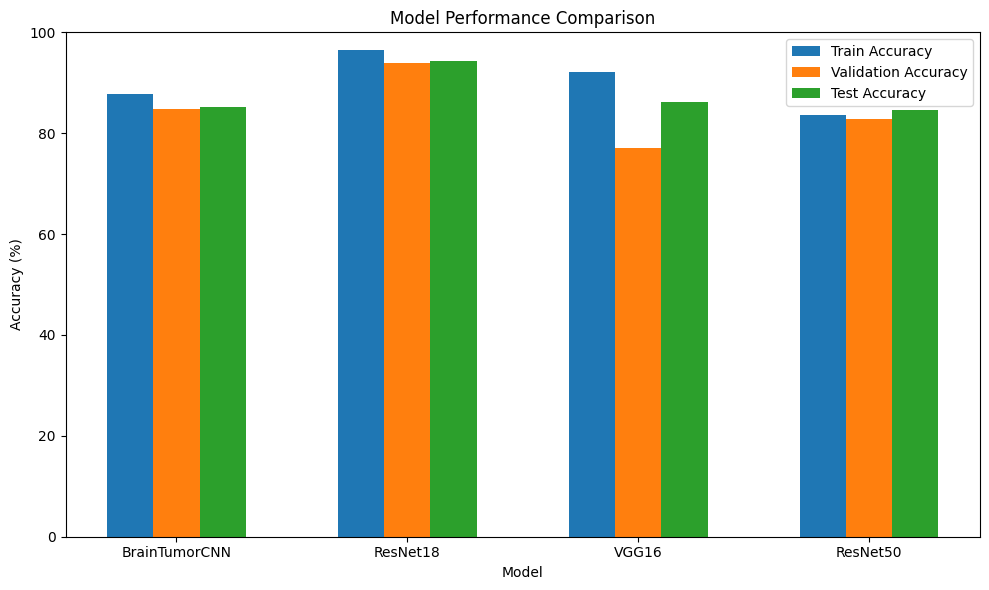

In [ ]:
# prompt: Now Compare all the models

# Compile comparison results
model_comparison = pd.DataFrame({
    'Model': ['BrainTumorCNN', 'ResNet18', 'VGG16', 'ResNet50'],
    'Training Accuracy': [history["train_acc"][-1], resnet_history["train_acc"][-1], vgg16_history["train_acc"][-1], resnet50_history["train_acc"][-1]],
    'Validation Accuracy': [history["val_acc"][-1], resnet_history["val_acc"][-1], vgg16_history["val_acc"][-1], resnet50_history["val_acc"][-1]]
})

print("\nModel Comparison:")
print(model_comparison)

# Optional: Evaluate on the test set for final comparison
# For a fair comparison, evaluate all models on the same test_loader
print("\nEvaluating models on Test Set for comparison...")

def get_test_accuracy(model, test_loader):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

cnn_test_acc = get_test_accuracy(model, test_loader)
resnet18_test_acc = get_test_accuracy(resnet18, test_loader)
vgg16_test_acc = get_test_accuracy(vgg16, test_loader)
resnet50_test_acc = get_test_accuracy(resnet50, test_loader)

model_comparison['Test Accuracy'] = [cnn_test_acc, resnet18_test_acc, vgg16_test_acc, resnet50_test_acc]

print("\nModel Comparison with Test Accuracy:")
print(model_comparison)

# Plot comparison (optional)
plt.figure(figsize=(10, 6))
bar_width = 0.2
index = np.arange(len(model_comparison))

bar1 = plt.bar(index, model_comparison['Training Accuracy'], bar_width, label='Train Accuracy')
bar2 = plt.bar(index + bar_width, model_comparison['Validation Accuracy'], bar_width, label='Validation Accuracy')
bar3 = plt.bar(index + 2 * bar_width, model_comparison['Test Accuracy'], bar_width, label='Test Accuracy')

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Model Performance Comparison")
plt.xticks(index + bar_width, model_comparison['Model'])
plt.legend()
plt.ylim(0, 100)
plt.tight_layout()
plt.show()



Based on Validation Accuracy, the best model is: ResNet18


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Loaded fine-tuned ResNet18 state dictionary for Grad-CAM.
Target layer for Grad-CAM is: layer4[-1].conv2 (last conv in the last block of ResNet18)

Performing Grad-CAM on the best model...

Visualizing Grad-CAM for image: /content/drive/MyDrive/M.Tech Projects/Brain Tumor Detection from MRI Images Using Deep Learning/Dataset/Brain Tumor MRI Dataset/Testing/pituitary/Te-piTr_0001.jpg
True Class: pituitary (ID: 3)


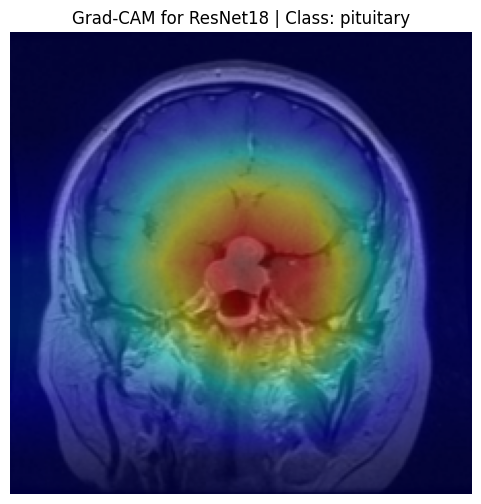

In [ ]:
# prompt: Now best model Grad Cam Implementation

# Identify the best performing model based on Validation Accuracy
best_model_name = model_comparison.loc[model_comparison['Validation Accuracy'].idxmax(), 'Model']
print(f"\nBased on Validation Accuracy, the best model is: {best_model_name}")

# Load the state dictionary of the best model
if best_model_name == 'BrainTumorCNN':
    best_model = BrainTumorCNN(num_classes=4).to(device)
    best_model.load_state_dict(torch.load("/content/drive/MyDrive/M.Tech Projects/Brain Tumor Detection from MRI Images Using Deep Learning/Models/brain_tumor_cnn.pth"))
    print("Loaded BrainTumorCNN state dictionary for Grad-CAM.")
    # Identify the target layer for Grad-CAM in BrainTumorCNN
    # Based on the architecture defined, the last convolutional layer is conv5
    target_layer = best_model.conv5
    print("Target layer for Grad-CAM is: conv5")

elif best_model_name == 'ResNet18':
    best_model = models.resnet18(pretrained=False) # Set pretrained=False as we load our fine-tuned weights
    num_features = best_model.fc.in_features
    best_model.fc = nn.Linear(num_features, 4)
    best_model.load_state_dict(torch.load('/content/drive/MyDrive/M.Tech Projects/Brain Tumor Detection from MRI Images Using Deep Learning/Models/resnet18_finetuned_model.pth'))
    best_model = best_model.to(device)
    print("Loaded fine-tuned ResNet18 state dictionary for Grad-CAM.")
    # Identify the target layer for Grad-CAM in ResNet18. Typically, it's the last convolutional layer before the global average pooling.
    # In ResNet, this is usually the final layer in the last block. For ResNet18, 'layer4' contains the final convolutional blocks.
    # We can target the last sequential block within layer4, and the last convolution within that.
    target_layer = best_model.layer4[-1].conv2 # Target the last conv in the last block of layer4
    print(f"Target layer for Grad-CAM is: layer4[-1].conv2 (last conv in the last block of ResNet18)")


elif best_model_name == 'VGG16':
    best_model = models.vgg16(pretrained=False) # Set pretrained=False as we load our fine-tuned weights
    best_model.classifier[-1] = nn.Linear(4096, 4)
    best_model.load_state_dict(torch.load('/content/drive/MyDrive/M.Tech Projects/Brain Tumor Detection from MRI Images Using Deep Learning/Models/vgg16_finetuned_model.pth'))
    best_model = best_model.to(device)
    print("Loaded fine-tuned VGG16 state dictionary for Grad-CAM.")
    # Identify the target layer for Grad-CAM in VGG16. It's typically the last convolutional layer in the features part.
    target_layer = best_model.features[28] # Index 28 corresponds to the last Conv2d layer in VGG16 features
    print("Target layer for Grad-CAM is: features[28] (last conv in VGG16)")


elif best_model_name == 'ResNet50':
    best_model = models.resnet50(pretrained=False) # Set pretrained=False as we load our fine-tuned weights
    num_features_resnet50 = best_model.fc.in_features
    best_model.fc = nn.Linear(num_features_resnet50, 4)
    best_model.load_state_dict(torch.load('/content/drive/MyDrive/M.Tech Projects/Brain Tumor Detection from MRI Images Using Deep Learning/Models/resnet50_finetuned_model.pth'))
    best_model = best_model.to(device)
    print("Loaded fine-tuned ResNet50 state dictionary for Grad-CAM.")
    # Identify the target layer for Grad-CAM in ResNet50. Similar to ResNet18, it's the last conv in the last block of layer4.
    target_layer = best_model.layer4[-1].conv3 # Target the last conv in the last block of layer4 for ResNet50
    print(f"Target layer for Grad-CAM is: layer4[-1].conv3 (last conv in the last block of ResNet50)")

else:
    print("Error: Could not determine the best model or target layer.")
    target_layer = None # Set target_layer to None to prevent errors

if target_layer is not None:
    print("\nPerforming Grad-CAM on the best model...")

    def compute_gradcam_best_model(model, target_layer, image_tensor, target_class=None):
        """
        Computes Grad-CAM heatmap for a given model and target layer.
        This is a more generalized version.
        """
        model.eval()
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model.to(device)

        image_tensor = image_tensor.unsqueeze(0).to(device)

        activations = None
        gradients = None

        def activations_hook(module, input, output):
            nonlocal activations
            activations = output

        def gradients_hook(module, grad_input, grad_output):
            nonlocal gradients
            gradients = grad_output[0]

        # Register hooks on the specified target layer
        hook_a = target_layer.register_forward_hook(activations_hook)
        # For some layers (like Linear), grad_output might be a tuple or list, use full_backward_hook
        hook_g = target_layer.register_full_backward_hook(gradients_hook)

        # Forward pass
        output = model(image_tensor)

        # Zero gradients
        model.zero_grad()

        # Get predicted class activation if target_class is not specified
        if target_class is None:
            _, target_class = torch.max(output, 1)
            target_class = target_class.item()

        if isinstance(target_class, torch.Tensor):
             target_class = target_class.item()

        # Compute gradient
        one_hot_output = torch.zeros(output.size()).to(device)
        one_hot_output[0][target_class] = 1
        # Use retain_graph=True if you might do more backward passes later (e.g., for multiple images in a batch)
        # For a single image, it might not be strictly necessary, but harmless.
        output.backward(gradient=one_hot_output, retain_graph=True)

        # Remove hooks
        hook_a.remove()
        hook_g.remove()

        # Ensure activations and gradients were captured
        if activations is None or gradients is None:
            print("Error: Activations or gradients were not captured. Check the target_layer.")
            return None

        # Process activations and gradients
        activations = activations.squeeze(0).cpu().data.numpy()
        gradients = gradients.squeeze(0).cpu().data.numpy()

        # Compute weights (alpha_k)
        weights = np.mean(gradients, axis=(1, 2))

        # Compute heatmap
        heatmap = np.sum(weights[:, None, None] * activations, axis=0)

        # Apply ReLU
        heatmap = np.maximum(heatmap, 0)

        # Normalize heatmap
        max_val = np.max(heatmap)
        if max_val == 0:
            heatmap = np.zeros_like(heatmap)
        else:
            heatmap = heatmap / max_val

        # Scale to 0-255 and resize
        heatmap = cv2.resize(heatmap, (224, 224)) # Resize to expected input size
        heatmap = np.uint8(255 * heatmap)

        # Overlay heatmap on original image
        # Need to denormalize the image tensor for display
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = image_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
        img = std * img + mean
        img = np.clip(img, 0, 1) * 255
        img = img.astype(np.uint8)

        heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        overlay = cv2.addWeighted(img_bgr, 0.6, heatmap_colored, 0.4, 0)

        plt.figure(figsize=(6,6))
        plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        label_names = list(label_map.keys())
        predicted_label_name = label_names[target_class]
        plt.title(f"Grad-CAM for {best_model_name} | Class: {predicted_label_name}")
        plt.show()

        return heatmap


    # Example usage with the best model and its specific target layer
    # Use the same sample image as before
    sample_image_path = "/content/drive/MyDrive/M.Tech Projects/Brain Tumor Detection from MRI Images Using Deep Learning/Dataset/Brain Tumor MRI Dataset/Testing/pituitary/Te-piTr_0001.jpg"
    sample_image_pil = Image.open(sample_image_path).convert("RGB")
    sample_image_tensor = test_transform(sample_image_pil) # Use the same transform used during testing/validation

    # Get the true label of the sample image
    true_label_name = sample_image_path.split('/')[-2]
    true_target_class = label_map[true_label_name]

    # Compute Grad-CAM using the best model, its target layer, the image tensor, and the true target class
    # You can also set target_class=None to visualize Grad-CAM for the model's predicted class
    print(f"\nVisualizing Grad-CAM for image: {sample_image_path}")
    print(f"True Class: {true_label_name} (ID: {true_target_class})")

    compute_gradcam_best_model(best_model, target_layer, sample_image_tensor, target_class=true_target_class)




--- Generating Grad-CAM visualizations for one image from each class ---

Processing image: /content/drive/MyDrive/M.Tech Projects/Brain Tumor Detection from MRI Images Using Deep Learning/Dataset/Brain Tumor MRI Dataset/Testing/notumor/Te-no_0316.jpg
True Class: notumor (ID: 0)
Generating Grad-CAM for the true class: notumor


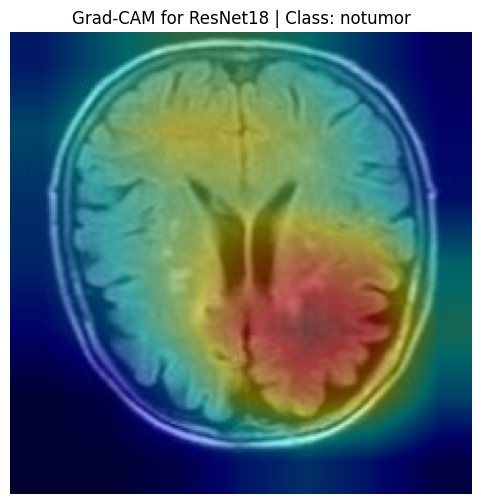


Processing image: /content/drive/MyDrive/M.Tech Projects/Brain Tumor Detection from MRI Images Using Deep Learning/Dataset/Brain Tumor MRI Dataset/Testing/glioma/Te-gl_0180.jpg
True Class: glioma (ID: 1)
Generating Grad-CAM for the true class: glioma


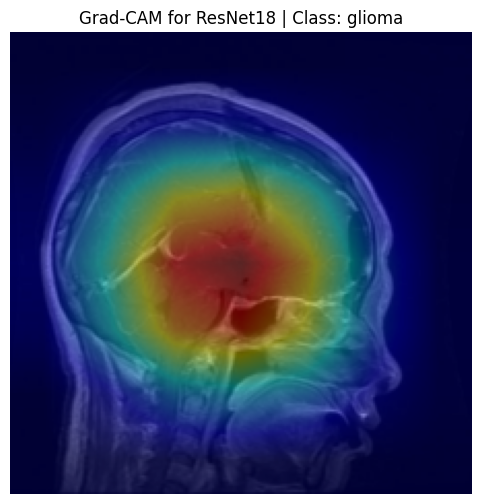


Processing image: /content/drive/MyDrive/M.Tech Projects/Brain Tumor Detection from MRI Images Using Deep Learning/Dataset/Brain Tumor MRI Dataset/Testing/meningioma/Te-me_0048.jpg
True Class: meningioma (ID: 2)
Generating Grad-CAM for the true class: meningioma


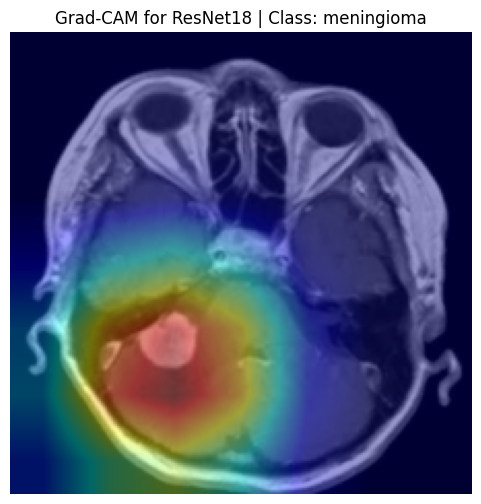


Processing image: /content/drive/MyDrive/M.Tech Projects/Brain Tumor Detection from MRI Images Using Deep Learning/Dataset/Brain Tumor MRI Dataset/Testing/pituitary/Te-pi_0217.jpg
True Class: pituitary (ID: 3)
Generating Grad-CAM for the true class: pituitary


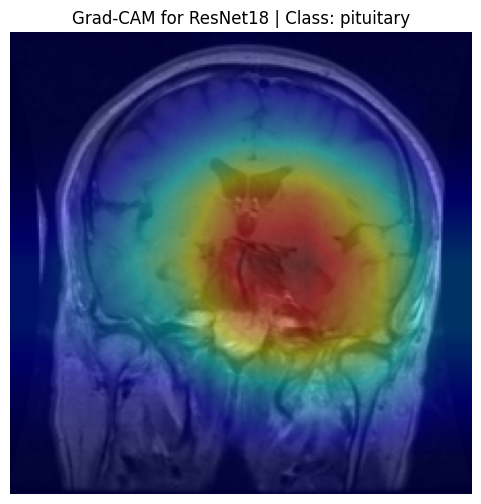

In [ ]:
# prompt: Take from each folder and want grad cam predictions

def compute_gradcam_for_all_folders(base_test_dir, label_map, model, transform, target_layer):
    """
    Iterates through each subfolder (class) in the test directory,
    picks one random image from each, and performs Grad-CAM.
    """
    print("\n--- Generating Grad-CAM visualizations for one image from each class ---")
    class_names = list(label_map.keys())

    for class_name in class_names:
        class_dir = os.path.join(base_test_dir, class_name)
        if not os.path.exists(class_dir) or not os.path.isdir(class_dir):
            print(f"Warning: Directory not found for class '{class_name}'. Skipping.")
            continue

        # List image files in the directory
        image_files = [f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f)) and f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if not image_files:
            print(f"Warning: No image files found in directory for class '{class_name}'. Skipping.")
            continue

        # Pick one random image
        sample_image_filename = random.choice(image_files)
        sample_image_path = os.path.join(class_dir, sample_image_filename)

        print(f"\nProcessing image: {sample_image_path}")
        true_target_class = label_map[class_name]
        print(f"True Class: {class_name} (ID: {true_target_class})")

        try:
            sample_image_pil = Image.open(sample_image_path).convert("RGB")
            sample_image_tensor = transform(sample_image_pil) # Use the same transform

            # Compute and display Grad-CAM
            # Setting target_class=true_target_class forces Grad-CAM for the true class
            # You can set target_class=None to see Grad-CAM for the model's predicted class
            print(f"Generating Grad-CAM for the true class: {class_name}")
            compute_gradcam_best_model(model, target_layer, sample_image_tensor, target_class=true_target_class)

        except Exception as e:
            print(f"Error processing image {sample_image_path}: {e}")
            continue


# Assuming 'best_model' and 'target_layer' have been determined
# And 'test_dir', 'label_map', 'test_transform' are available from the previous code

if 'best_model' in locals() and 'target_layer' in locals() and target_layer is not None:
    compute_gradcam_for_all_folders(test_dir, label_map, best_model, test_transform, target_layer)
else:
    print("Best model or target layer was not successfully identified. Cannot proceed with folder-wise Grad-CAM.")


In [ ]:
# prompt: Now I want User Interface Gradio for this project predications dont include gradcam

!pip install gradio -qq
import gradio as gr
import torch
from PIL import Image
import torchvision.transforms as transforms

# Assuming 'best_model', 'test_transform', and 'label_map' are defined and loaded from your previous code

# Define the function for Gradio interface
def classify_image(image):
    """
    Predicts the brain tumor class from an uploaded image and returns the prediction.
    """
    # Convert Gradio image (numpy array) to PIL Image
    img_pil = Image.fromarray(image.astype('uint8'), 'RGB')

    # Apply the same test transform used during training/evaluation
    img_tensor = test_transform(img_pil).unsqueeze(0).to(device) # Add batch dimension and send to device

    best_model.eval() # Set model to evaluation mode

    with torch.no_grad():
        outputs = best_model(img_tensor)
        _, predicted_class_idx = torch.max(outputs, 1)
        probabilities = torch.softmax(outputs, dim=1)[0] # Get probabilities

    # Map predicted index back to class name
    class_names = list(label_map.keys())
    predicted_label = class_names[predicted_class_idx.item()]

    # Format probabilities for output
    confidences = {class_names[i]: float(probabilities[i]) for i in range(len(class_names))}

    return predicted_label, confidences

# Create the Gradio interface
iface = gr.Interface(
    fn=classify_image,
    inputs=gr.Image(type="numpy"), # Expects image as numpy array
    outputs=[
        gr.Label(num_top_classes=4), # Displays the predicted class with top 4 probabilities
        gr.Label(num_top_classes=4)  # Duplicate label for probabilities if needed, or remove
    ],
    title="Brain Tumor Classification",
    description="Upload a brain MRI image to get a prediction of the tumor type (or no tumor).",
    live=True
)

# Launch the interface
iface.launch(debug=True)

It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://027a252a3eb7e5e888.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Using existing dataset file at: .gradio/flagged/dataset1.csv
